In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, round as spark_round

spark = SparkSession.builder \
    .appName("PISA-Global-Analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.4.0") \
    .getOrCreate()

26/04/06 19:58:55 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/06 19:58:55 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [5]:
from pyspark.sql.functions import col, avg, round as spark_round, lit

def get_global_stats(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    
    # 1. Valitaan oikea ICT-sarake vuoden mukaan
    # 2012: Käytetään itse luotua summaa (ICTAVHOM_SUM)
    # 2022: Käytetään valmista WLE-indeksiä (ICTAVHOM)
    ict_col = "ICTAVHOM_SUM" if year == 2012 else "ICTAVHOM"
    
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load()
    
    # Valitaan tarvittavat sarakkeet ja suodatetaan null-arvot
    # Lisätty PV1READ mukaan analyysiin
    clean_df = df.select("PV1MATH", "PV1READ", ict_col, "CNT") \
                 .filter(
                     col("PV1MATH").isNotNull() & 
                     col(ict_col).isNotNull()
                 )
    
    # Lasketaan keskiarvot
    averages = clean_df.select(
        spark_round(avg("PV1MATH"), 2).alias("avg_math"),
        spark_round(avg("PV1READ"), 2).alias("avg_read"),
        spark_round(avg(ict_col), 2).alias("avg_ict")
    ).collect()[0]
    
    # Lasketaan globaalit korrelaatiot
    corr_ict_math = clean_df.stat.corr(ict_col, "PV1MATH")
    corr_ict_read = clean_df.stat.corr(ict_col, "PV1READ")
    
    return {
        "math": averages["avg_math"],
        "read": averages["avg_read"],
        "ict": averages["avg_ict"],
        "ict_col_name": ict_col, # Tallennetaan nimi muistiin tulosteita varten
        "corr_ict_math": corr_ict_math,
        "corr_ict_read": corr_ict_read,
        "count": clean_df.count()
    }

try:
    print("\n" + "="*70)
    print("GLOBAALI PISA-VERTAILU: 2012 vs 2022 (KAIKKI MAAT)")
    print("="*70)
    
    stats_12 = get_global_stats(2012)
    stats_22 = get_global_stats(2022)
    
    # Tulostetaan taulukko
    template = "{:<30} {:<20} {:<20}"
    print(template.format("Mittari", "Vuosi 2012", "Vuosi 2022"))
    print("-" * 70)
    print(template.format("Matematiikka (ka)", stats_12['math'], stats_22['math']))
    print(template.format("Lukutaito (ka)", stats_12['read'], stats_22['read']))
    print(template.format("ICT-muuttuja käytössä", stats_12['ict_col_name'], stats_22['ict_col_name']))
    print(template.format("ICT-keskiarvo (huom! eri asteikot)", stats_12['ict'], stats_22['ict']))
    print("-" * 70)
    print(template.format("ICT-Matikka Korrelaatio", f"{stats_12['corr_ict_math']:.3f}", f"{stats_22['corr_ict_math']:.3f}"))
    print(template.format("ICT-Lukutaito Korrelaatio", f"{stats_12['corr_ict_read']:.3f}", f"{stats_22['corr_ict_read']:.3f}"))
    print("-" * 70)
    print(f"Data-pisteitä yhteensä: 2012: {stats_12['count']} | 2022: {stats_22['count']}")

except Exception as e:
    print(f"Virhe analyysissä: {e}")


GLOBAALI PISA-VERTAILU: 2012 vs 2022 (KAIKKI MAAT)


Mittari                        Vuosi 2012           Vuosi 2022          
----------------------------------------------------------------------
Matematiikka (ka)              469.41               464.16              
Lukutaito (ka)                 471.61               461.25              
ICT-muuttuja käytössä          ICTAVHOM_SUM         ICTAVHOM            
ICT-keskiarvo (huom! eri asteikot) 25.27                5.57                
----------------------------------------------------------------------
ICT-Matikka Korrelaatio        0.254                0.186               
ICT-Lukutaito Korrelaatio      0.229                0.187               
----------------------------------------------------------------------
Data-pisteitä yhteensä: 2012: 480174 | 2022: 343200


In [6]:
from pyspark.sql.functions import col, when, avg, round as spark_round, count, lit

def get_global_usage_stats(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    
    # Valitaan vain kriittiset sarakkeet muistin säästämiseksi
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load() \
        .select("PV1MATH", "PV1READ", "ICTWKDY")
    
    # Määritetään Usage_Group vuoden mukaan (erilaiset asteikot)
    if year == 2012:
        # 2012: Kategorinen 1-7
        df_grouped = df.withColumn("Usage_Group", 
            when(col("ICTWKDY").isin(1, 2, 3), "1. Low (0-1h)")
            .when(col("ICTWKDY").isin(4, 5), "2. Moderate (1-4h)")
            .when(col("ICTWKDY").isin(6, 7), "3. Heavy (4h+)")
            .otherwise(None))
    else:
        # 2022: WLE-indeksi (liukuluku)
        df_grouped = df.withColumn("Usage_Group", 
            when(col("ICTWKDY") < -0.5, "1. Low (Below Avg)")
            .when((col("ICTWKDY") >= -0.5) & (col("ICTWKDY") <= 1.0), "2. Moderate (Avg)")
            .when(col("ICTWKDY") > 1.0, "3. Heavy (High Use)")
            .otherwise(None))

    # Suodatetaan nullit ja lasketaan globaalit keskiarvot ryhmittäin
    stats = df_grouped.filter(col("Usage_Group").isNotNull()) \
        .groupBy("Usage_Group") \
        .agg(
            spark_round(avg("PV1MATH"), 1).alias("Global_Math"),
            spark_round(avg("PV1READ"), 1).alias("Global_Read"),
            count("*").alias("Global_N")
        ).orderBy("Usage_Group")
    
    return stats.collect() # Palauttaa tulokset listana ajurille

# --- SUORITUS JA VERTAILU ---
try:
    print("\n" + "="*80)
    print("GLOBAALI ANALYYSI: INTERNET-AIKA VS. OSAAMINEN")
    print("="*80)

    global_stats_12 = get_global_usage_stats(2012)
    global_stats_22 = get_global_usage_stats(2022)

    def print_table(data, year):
        print(f"\nVuosi {year}:")
        header = "{:<25} | {:<12} | {:<12} | {:<10}"
        print(header.format("Käyttöryhmä", "Math (ka)", "Read (ka)", "Oppilaita"))
        print("-" * 70)
        for row in data:
            print(header.format(row['Usage_Group'], row['Global_Math'], row['Global_Read'], row['Global_N']))

    print_table(global_stats_12, 2012)
    print_table(global_stats_22, 2022)

except Exception as e:
    print(f"Virhe globaalissa analyysissä: {e}")


GLOBAALI ANALYYSI: INTERNET-AIKA VS. OSAAMINEN



Vuosi 2012:
Käyttöryhmä               | Math (ka)    | Read (ka)    | Oppilaita 
----------------------------------------------------------------------
1. Low (0-1h)             | 489.0        | 486.6        | 95394     
2. Moderate (1-4h)        | 498.9        | 500.4        | 148661    
3. Heavy (4h+)            | 473.8        | 475.4        | 51133     

Vuosi 2022:
Käyttöryhmä               | Math (ka)    | Read (ka)    | Oppilaita 
----------------------------------------------------------------------
1. Low (Below Avg)        | 484.8        | 479.2        | 84933     
2. Moderate (Avg)         | 474.0        | 473.7        | 192116    
3. Heavy (High Use)       | 414.1        | 406.6        | 46897     


In [7]:
from pyspark.sql.functions import col

def get_global_correlations(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    
    # Valitaan muuttujat
    ict_avail_col = "ICTAVHOM_SUM" if year == 2012 else "ICTAVHOM"
    
    # Ladataan vain tarvittavat sarakkeet
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load() \
        .select("PV1MATH", "PV1READ", "ICTWKDY", ict_avail_col, "ESCS")
    
    # Siivotaan null-arvot pois laskentaa varten
    clean_df = df.filter(
        col("PV1MATH").isNotNull() & 
        col("PV1READ").isNotNull() & 
        col("ICTWKDY").isNotNull() & 
        col(ict_avail_col).isNotNull()
    )

    # Lasketaan korrelaatiot (Pearson)
    # 1. Ruutuaika vs. Osaaminen
    corr_usage_math = clean_df.stat.corr("ICTWKDY", "PV1MATH")
    corr_usage_read = clean_df.stat.corr("ICTWKDY", "PV1READ")
    
    # 2. Laitteiden saatavuus vs. Osaaminen
    corr_avail_math = clean_df.stat.corr(ict_avail_col, "PV1MATH")
    corr_avail_read = clean_df.stat.corr(ict_avail_col, "PV1READ")
    
    # 3. Vertailun vuoksi: Kotitausta (ESCS) vs. Osaaminen
    corr_escs_math = clean_df.stat.corr("ESCS", "PV1MATH")

    return {
        "usage_math": corr_usage_math,
        "usage_read": corr_usage_read,
        "avail_math": corr_avail_math,
        "avail_read": corr_avail_read,
        "escs_math": corr_escs_math,
        "count": clean_df.count()
    }

# --- AJO JA TULOKSET ---
try:
    print("\n" + "="*70)
    print("GLOBAALIT KORRELAATIOT: DIGITAALINEN MURROS (N ~ 600,000+)")
    print("="*70)

    g_12 = get_global_correlations(2012)
    g_22 = get_global_correlations(2022)

    template = "{:<35} | {:<12} | {:<12}"
    print(template.format("Korrelaatio (r)", "2012", "2022"))
    print("-" * 70)
    print(template.format("Ruutuaika vs. Matematiikka", f"{g_12['usage_math']:.3f}", f"{g_22['usage_math']:.3f}"))
    print(template.format("Ruutuaika vs. Lukutaito", f"{g_12['usage_read']:.3f}", f"{g_22['usage_read']:.3f}"))
    print(template.format("Laitteet (koti) vs. Matematiikka", f"{g_12['avail_math']:.3f}", f"{g_22['avail_math']:.3f}"))
    print(template.format("Laitteet (koti) vs. Lukutaito", f"{g_12['avail_read']:.3f}", f"{g_22['avail_read']:.3f}"))
    print(template.format("Kotitausta (ESCS) vs. Matematiikka", f"{g_12['escs_math']:.3f}", f"{g_22['escs_math']:.3f}"))
    print("-" * 70)
    print(f"Data-pisteitä: 2012: {g_12['count']} | 2022: {g_22['count']}")

except Exception as e:
    print(f"Virhe: {e}")


GLOBAALIT KORRELAATIOT: DIGITAALINEN MURROS (N ~ 600,000+)


Korrelaatio (r)                     | 2012         | 2022        
----------------------------------------------------------------------
Ruutuaika vs. Matematiikka          | -0.269       | -0.162      
Ruutuaika vs. Lukutaito             | -0.247       | -0.151      
Laitteet (koti) vs. Matematiikka    | 0.254        | 0.129       
Laitteet (koti) vs. Lukutaito       | 0.229        | 0.128       
Kotitausta (ESCS) vs. Matematiikka  | -0.104       | 0.425       
----------------------------------------------------------------------
Data-pisteitä: 2012: 480174 | 2022: 318087


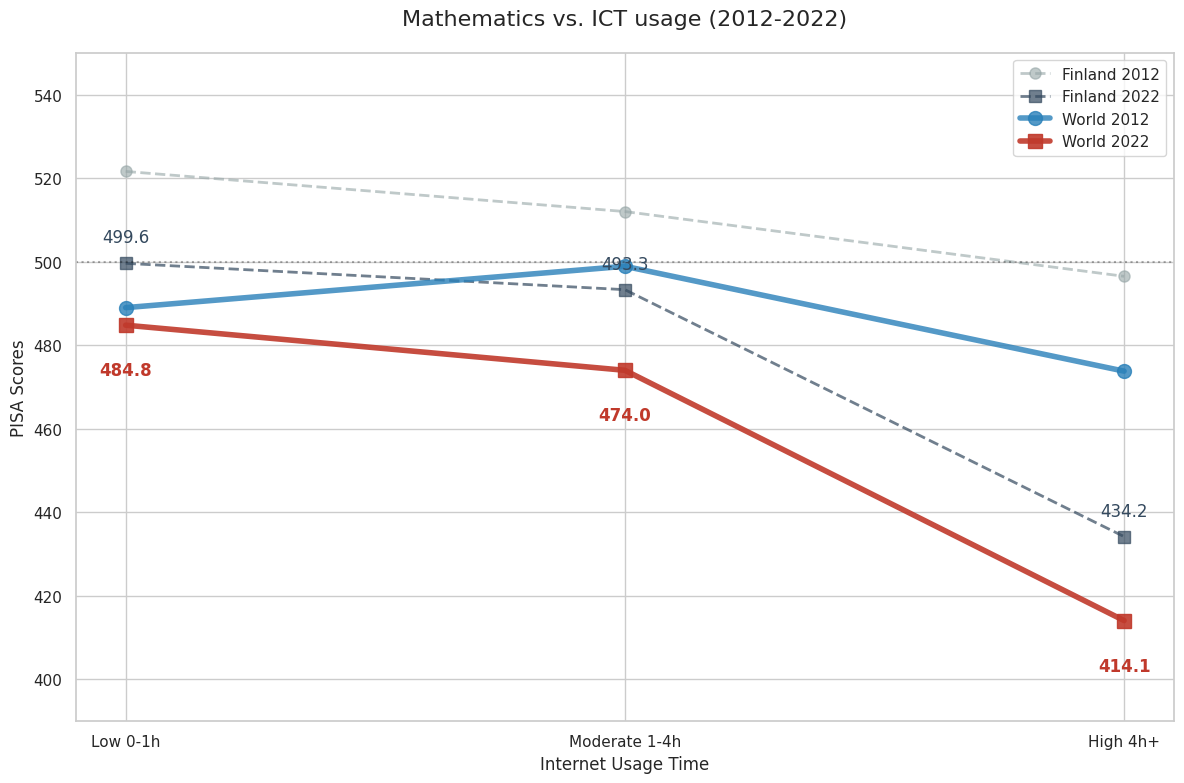

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA MATHEMATICS ---
usage_labels = ['Low 0-1h', 'Moderate 1-4h', 'High 4h+']

# Finnish results (from your previous analysis)
fin_2012 = [521.6, 512.0, 496.5]
fin_2022 = [499.6, 493.3, 434.2]

# Global results
glob_2012 = [489.0, 498.9, 473.8]
glob_2022 = [484.8, 474.0, 414.1]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")


plt.plot(usage_labels, fin_2012, marker='o', markersize=8, linewidth=2, linestyle='--',
         color='#95a5a6', label='Finland 2012', alpha=0.6)
plt.plot(usage_labels, fin_2022, marker='s', markersize=8, linewidth=2, linestyle='--',
         color='#34495e', label='Finland 2022', alpha=0.7) 


plt.plot(usage_labels, glob_2012, marker='o', markersize=10, linewidth=4, color='#2980b9', label='World 2012', alpha=0.8) #2980b9
plt.plot(usage_labels, glob_2022, marker='s', markersize=10, linewidth=4, color='#c0392b', label='World 2022', alpha=0.9)


for i, val in enumerate(fin_2022):
    plt.text(i, val + 5, f'{val}', ha='center', color='#34495e') 
for i, val in enumerate(glob_2022):
    plt.text(i, val - 12, f'{val}', ha='center', color='#c0392b', fontweight='bold')


plt.title('Mathematics vs. ICT usage (2012-2022)', fontsize=16, pad=20)
plt.ylabel('PISA Scores', fontsize=12)
plt.xlabel('Internet Usage Time', fontsize=12)
plt.ylim(390, 550)
plt.legend(loc='upper right', fontsize=11)
plt.axhline(500, color='black', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

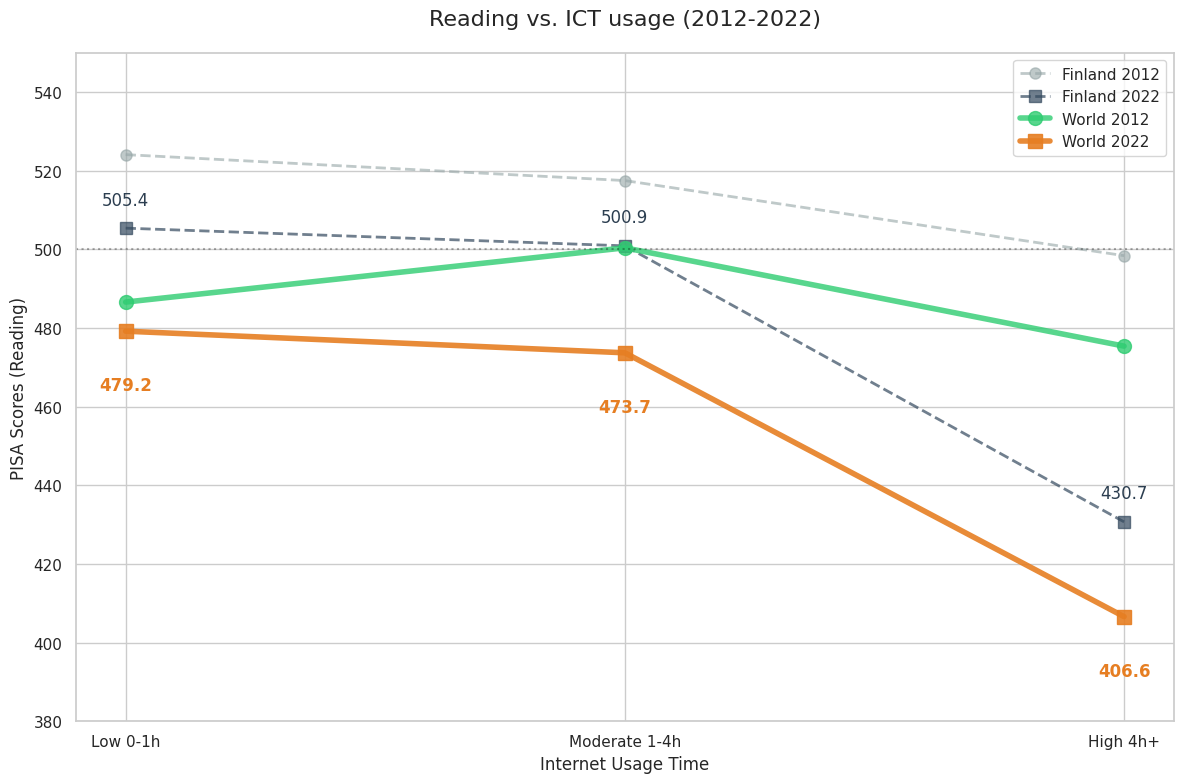

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA READING ---
usage_labels = ['Low 0-1h', 'Moderate 1-4h', 'High 4h+']

# Finnish results (Reading)
fin_read_2012 = [524.1, 517.5, 498.4]
fin_read_2022 = [505.4, 500.9, 430.7]

# Global results (Reading)
glob_read_2012 = [486.6, 500.4, 475.4]
glob_read_2022 = [479.2, 473.7, 406.6]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")


plt.plot(usage_labels, fin_read_2012, marker='o', markersize=8, linewidth=2, linestyle='--',
         color='#95a5a6', label='Finland 2012', alpha=0.6)
plt.plot(usage_labels, fin_read_2022, marker='s', markersize=8, linewidth=2, linestyle='--',
         color='#34495e', label='Finland 2022', alpha=0.7) 


plt.plot(usage_labels, glob_read_2012, marker='o', markersize=10, linewidth=4, color='#2ecc71', label='World 2012', alpha=0.8) 
plt.plot(usage_labels, glob_read_2022, marker='s', markersize=10, linewidth=4, color='#e67e22', label='World 2022', alpha=0.9)


for i, val in enumerate(fin_read_2022):
    plt.text(i, val + 6, f'{val}', ha='center', color='#2c3e50') 
for i, val in enumerate(glob_read_2022):
    plt.text(i, val - 15, f'{val}', ha='center', color='#e67e22', fontweight='bold')

# Muotoilu
plt.title('Reading vs. ICT usage (2012-2022)', fontsize=16, pad=20)
plt.ylabel('PISA Scores (Reading)', fontsize=12)
plt.xlabel('Internet Usage Time', fontsize=12)
plt.ylim(380, 550)
plt.legend(loc='upper right', fontsize=11)
plt.axhline(500, color='black', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()